In [2]:
import csv
import sys

csv.field_size_limit(sys.maxsize)

with open("Fixed_news_dataset.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    data = list(reader)

    # Lấy danh sách field names (tên cột)
    fieldnames = reader.fieldnames
    
    

In [3]:
print(f"Tổng số mẫu: {len(data)}")
# print(data[0])
# In ra tất cả các field
print("Các field trong CSV:")
for field in fieldnames:
    print(field)

Tổng số mẫu: 184539
Các field trong CSV:
Unnamed: 0.1
Unnamed: 0
id
author
content
picture_count
processed
source
title
topic
url
crawled_at


In [4]:
topics = []
for i in data:
    if i["topic"] not in topics:
        topics.append(i["topic"])
        print(i["topic"])

Pháp luật
Sức khỏe - Đời sống
Giáo dục
Thế giới
Thời sự
Văn hóa - Giải trí
Thể thao
Xã hội
Bất động sản
Công nghệ
Kinh tế
Kinh doanh - Tài chính
Bạn đọc
Chính trị
Quốc phòng
Xe
Pháp luật


In [5]:
economical_topics = {"Bất động sản", "Kinh tế", "Kinh doanh - Tài chính"}

for i in data:
    i["label"] = 1 if i["topic"] in economical_topics else 0

In [6]:
import random

random.seed(42)

data_label_1 = [i for i in data if i["label"] == 1]
data_label_0 = [i for i in data if i["label"] == 0]

sample_label_1 = random.sample(data_label_1, 3000)
sample_label_0 = random.sample(data_label_0, 17000)

sample_dataset = sample_label_1 + sample_label_0
random.shuffle(sample_dataset)

# Kiểm tra tỉ lệ
count_label_1 = sum(1 for i in sample_dataset if i["label"] == 1)
count_label_0 = sum(1 for i in sample_dataset if i["label"] == 0)
ratio_label_1 = count_label_1 / len(sample_dataset)
ratio_label_0 = count_label_0 / len(sample_dataset)

print(f"Tổng số mẫu: {len(sample_dataset)}")
print(f"Số mẫu label 1: {count_label_1} ({ratio_label_1:.2%})")
print(f"Số mẫu label 0: {count_label_0} ({ratio_label_0:.2%})")

Tổng số mẫu: 20000
Số mẫu label 1: 3000 (15.00%)
Số mẫu label 0: 17000 (85.00%)


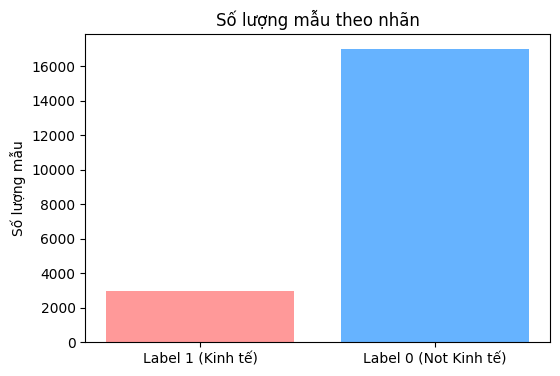

In [58]:
import matplotlib.pyplot as plt

# Dữ liệu cho biểu đồ
labels = ['Label 1 (Kinh tế)', 'Label 0 (Not Kinh tế)']
counts = [count_label_1, count_label_0]


# Biểu đồ cột
plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=['#ff9999','#66b3ff'])
plt.ylabel('Số lượng mẫu')
plt.title('Số lượng mẫu theo nhãn')
plt.show()

### Pre-processing

In [6]:
vietnamese_stopwords = set([
    'bị', 'bởi', 'cả', 'các', 'cái', 'cần', 'càng', 'chỉ', 'chiếc',
    'cho', 'chứ', 'chưa', 'chuyện', 'có', 'có_thể', 'cứ', 'của', 'cùng',
    'cũng', 'đã', 'đang', 'đây', 'để', 'đến_nỗi', 'đều', 'điều', 'do',
    'đó', 'được', 'dưới', 'gì', 'khi', 'không', 'là', 'lại', 'lên', 'lúc',
    'mà', 'mỗi', 'một_cách', 'này', 'nên', 'nếu', 'ngay', 'nhiều', 'như',
    'nhưng', 'những', 'nơi', 'nữa', 'phải', 'qua', 'ra', 'rằng', 'rất',
    'rồi', 'sau', 'sẽ', 'so', 'sự', 'tại', 'theo', 'thì', 'trên', 'trước',
    'từ', 'từng', 'và', 'vẫn', 'vào', 'vậy', 'vì', 'việc', 'với', 'vừa'
])

In [8]:
import re
from underthesea import word_tokenize

def preprocess_texts_vn(texts, stopwords=None, lowercase=True, remove_punct=True, return_tokens=False):
    processed_texts = []
    
    for text in texts:
        # 1. Chuyển lowercase
        if lowercase:
            text = text.lower()
        
        # 2. Xóa ký tự đặc biệt, số, dấu câu
        if remove_punct:
            text = re.sub(r'[^\w\s]', ' ', text)  # loại bỏ punctuation
            text = re.sub(r'\d+', ' ', text)      # loại bỏ số
            text = re.sub(r'\s+', ' ', text)      # loại bỏ khoảng trắng thừa
            text = text.strip()
        
        # 3. Tokenize
        tokens = word_tokenize(text, format="text").split()
        
        # 4. Loại bỏ stopwords
        if stopwords:
            tokens = [t for t in tokens if t not in stopwords]
        
        # 5. Trả về token hoặc string
        if return_tokens:
            processed_texts.append(tokens)
        else:
            processed_texts.append(' '.join(tokens))
    
    return processed_texts


In [ ]:
texts = [item["title"] for item in sample_dataset]
texts

# Tiền xử lý trả về chuỗi sạch
texts_clean = preprocess_texts_vn(texts, stopwords=vietnamese_stopwords)
texts_clean[0]

### Split data for train

In [63]:
texts = texts_clean
label = [i["label"] for i in sample_dataset]

print(texts[8])
print(label[8])
print(len(texts))
print(len(label))

cử_tri đề_nghị công_khai công_trình_tốc châu_đốc thơ_sóc trăng
0
20000
20000


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    texts, label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

import numpy as np

y_train = np.array(y_train)
y_test = np.array(y_test)

print(len(X_train))
print( len(X_test))
print(len(y_train))
print(len(y_test))
print(sum(y_test == 0), sum(y_test == 1))

16000
4000
16000
4000
3400 600


### Vectorizer

In [20]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [21]:
def evaluate_and_print(model_name, vectorizer_name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)

    print(f"=== Model: {model_name} | Vectorizer: {vectorizer_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(report)
    print("\n")

In [22]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
def run_experiment(vectorizers, models, X_train, X_test, y_train, y_test):
    results = []

    for vec_name, vectorizer in vectorizers.items():
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)

        for model_name, model in models.items():
            model.fit(X_train_vec, y_train)

            y_pred = model.predict(X_test_vec)

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
            precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
            recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)

            evaluate_and_print(model_name, vec_name, y_test, y_pred)

            cm = confusion_matrix(y_test, y_pred)

            plt.figure(figsize=(5,4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f'Confusion Matrix - {model_name} + {vec_name}')
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.show()

            results.append({
                "vectorizer": vec_name,
                "model": model_name,
                "accuracy": acc,
                "f1": f1,
                "precision": precision,
                "recall": recall,
                "cm": cm
            })

    return results

In [24]:
def get_best_accuracy(results):
    best_acc = max(results, key=lambda x: x['accuracy'])
    
    print("=== Best Accuracy ===")
    print(f"Vectorizer: {best_acc['vectorizer']}")
    print(f"Model: {best_acc['model']}")
    print(f"Accuracy: {best_acc['accuracy']:.4f}")
    
    return best_acc



In [25]:
def get_best_f1_label1(results):
    best_f1 = max(results, key=lambda x: x['f1'])
    
    print("=== Best model for class 1 (Kinh tế/Kinh doanh) ===")
    print(f"Vectorizer: {best_f1['vectorizer']}")
    print(f"Model: {best_f1['model']}")
    print(f"Accuracy: {best_f1['accuracy']:.4f}")
    print(f"Precision: {best_f1['precision']:.4f}")
    print(f"Recall: {best_f1['recall']:.4f}")
    print(f"F1: {best_f1['f1']:.4f}")
    
    return best_f1



### Ban đầu

In [35]:
vectorizers = {
    "Bow": CountVectorizer(),
    "TF-IDF": TfidfVectorizer()
}

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter = 1000),
    "SVM": SVC(kernel="linear")
}

=== Model: Naive Bayes | Vectorizer: Bow ===
Accuracy : 0.9113
Precision: 0.7316
Recall   : 0.6450
F1-score : 0.6856
Confusion Matrix:
[[3258  142]
 [ 213  387]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3400
           1       0.73      0.65      0.69       600

    accuracy                           0.91      4000
   macro avg       0.84      0.80      0.82      4000
weighted avg       0.91      0.91      0.91      4000





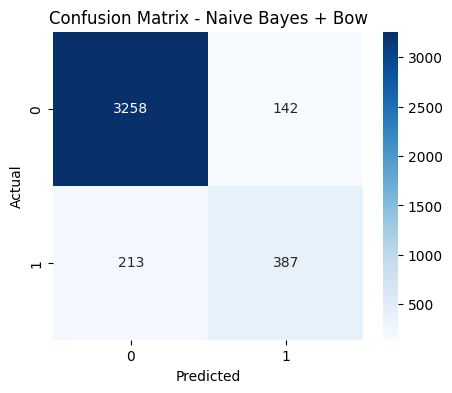

=== Model: Logistic Regression | Vectorizer: Bow ===
Accuracy : 0.9115
Precision: 0.7915
Recall   : 0.5567
F1-score : 0.6536
Confusion Matrix:
[[3312   88]
 [ 266  334]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3400
           1       0.79      0.56      0.65       600

    accuracy                           0.91      4000
   macro avg       0.86      0.77      0.80      4000
weighted avg       0.91      0.91      0.90      4000





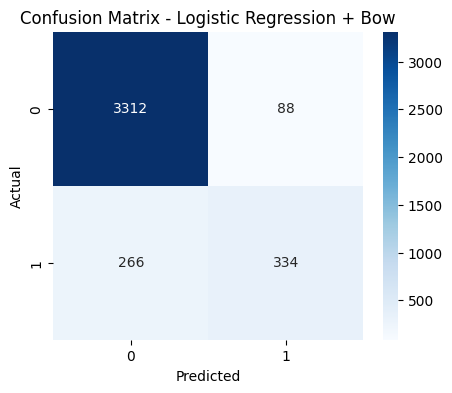

=== Model: SVM | Vectorizer: Bow ===
Accuracy : 0.9083
Precision: 0.7138
Recall   : 0.6483
F1-score : 0.6795
Confusion Matrix:
[[3244  156]
 [ 211  389]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      3400
           1       0.71      0.65      0.68       600

    accuracy                           0.91      4000
   macro avg       0.83      0.80      0.81      4000
weighted avg       0.91      0.91      0.91      4000





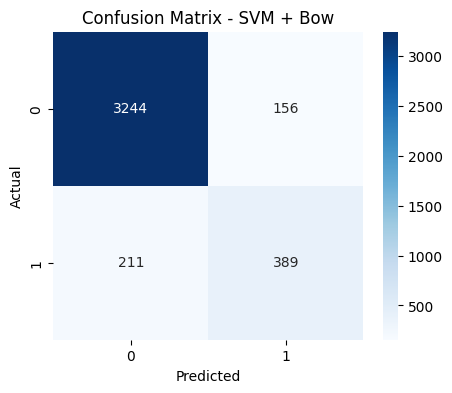

=== Model: Naive Bayes | Vectorizer: TF-IDF ===
Accuracy : 0.8782
Precision: 0.9007
Recall   : 0.2117
F1-score : 0.3428
Confusion Matrix:
[[3386   14]
 [ 473  127]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      3400
           1       0.90      0.21      0.34       600

    accuracy                           0.88      4000
   macro avg       0.89      0.60      0.64      4000
weighted avg       0.88      0.88      0.84      4000





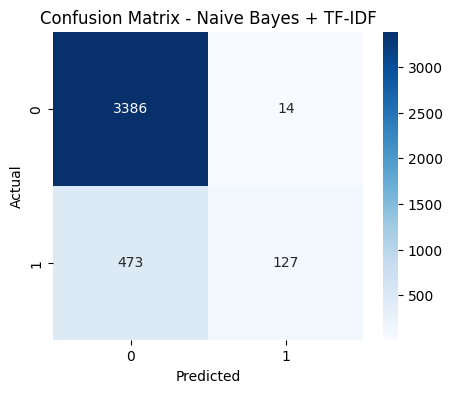

=== Model: Logistic Regression | Vectorizer: TF-IDF ===
Accuracy : 0.9045
Precision: 0.8263
Recall   : 0.4600
F1-score : 0.5910
Confusion Matrix:
[[3342   58]
 [ 324  276]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      3400
           1       0.83      0.46      0.59       600

    accuracy                           0.90      4000
   macro avg       0.87      0.72      0.77      4000
weighted avg       0.90      0.90      0.89      4000





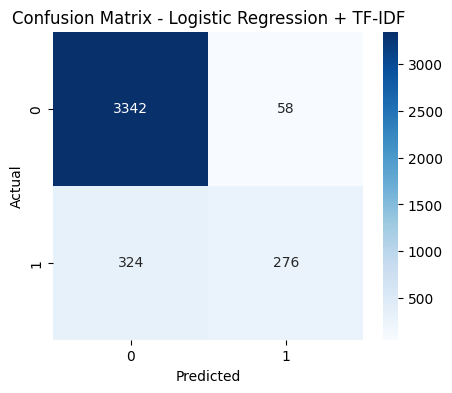

=== Model: SVM | Vectorizer: TF-IDF ===
Accuracy : 0.9167
Precision: 0.7896
Recall   : 0.6067
F1-score : 0.6861
Confusion Matrix:
[[3303   97]
 [ 236  364]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3400
           1       0.79      0.61      0.69       600

    accuracy                           0.92      4000
   macro avg       0.86      0.79      0.82      4000
weighted avg       0.91      0.92      0.91      4000





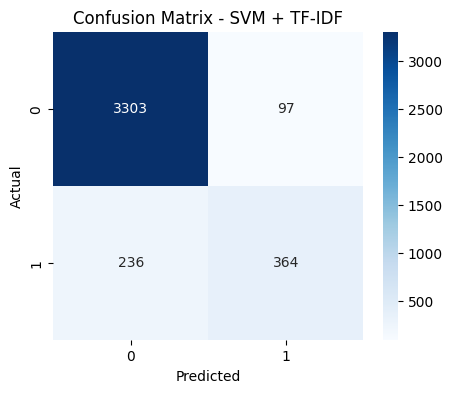

=== Best Accuracy ===
Vectorizer: TF-IDF
Model: SVM
Accuracy: 0.9167
=== Best model for class 1 (Kinh tế/Kinh doanh) ===
Vectorizer: TF-IDF
Model: SVM
Accuracy: 0.9167
Precision: 0.7896
Recall: 0.6067
F1: 0.6861


In [36]:
results_0 = run_experiment(vectorizers, models, X_train, X_test, y_train, y_test)
best_acc_0 = get_best_accuracy(results_0)
best_f1_0 = get_best_f1_label1(results_0)

### HƯớng 1: Giảm số lượng đặc trưng
```1. Lý do thử
Dữ liệu text có số chiều rất lớn (sparse)
Nhiều feature không quan trọng → gây nhiễu, overfitting
Giảm feature giúp:
tăng tốc
giảm noise
có thể cải thiện F1
```

In [32]:
vectorizers = {
    "TFIDF_5k_clean": TfidfVectorizer(
        max_features=5000,
        min_df=5,
        max_df=0.8
    ),
    "TFIDF_10k_clean": TfidfVectorizer(
        max_features=10000,
        min_df=3,
        max_df=0.85
    ),
    "Bow_5k_clean": CountVectorizer(
        max_features=5000,
        min_df=5,
        max_df=0.8
    ),
    "Bow_10k_clean": CountVectorizer(
        max_features=10000,
        min_df=3,
        max_df=0.85
    ),
}


In [33]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter = 1000),
    "SVM": SVC(kernel="linear")
}

=== Model: Naive Bayes | Vectorizer: TFIDF_5k_clean ===
Accuracy : 0.9048
Precision: 0.8269
Recall   : 0.4617
F1-score : 0.5925
Confusion Matrix:
[[3342   58]
 [ 323  277]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      3400
           1       0.83      0.46      0.59       600

    accuracy                           0.90      4000
   macro avg       0.87      0.72      0.77      4000
weighted avg       0.90      0.90      0.89      4000





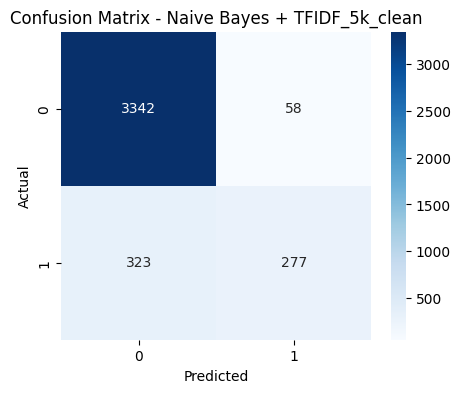

=== Model: Logistic Regression | Vectorizer: TFIDF_5k_clean ===
Accuracy : 0.9038
Precision: 0.8116
Recall   : 0.4667
F1-score : 0.5926
Confusion Matrix:
[[3335   65]
 [ 320  280]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      3400
           1       0.81      0.47      0.59       600

    accuracy                           0.90      4000
   macro avg       0.86      0.72      0.77      4000
weighted avg       0.90      0.90      0.89      4000





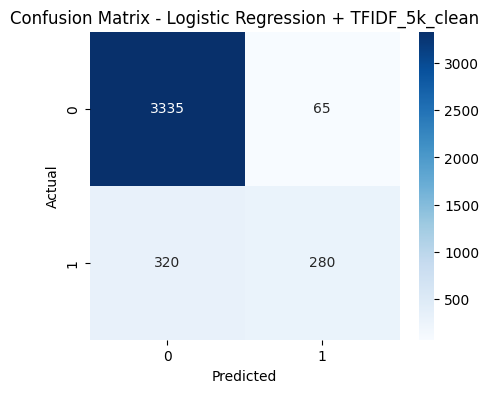

=== Model: SVM | Vectorizer: TFIDF_5k_clean ===
Accuracy : 0.9155
Precision: 0.8032
Recall   : 0.5783
F1-score : 0.6725
Confusion Matrix:
[[3315   85]
 [ 253  347]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3400
           1       0.80      0.58      0.67       600

    accuracy                           0.92      4000
   macro avg       0.87      0.78      0.81      4000
weighted avg       0.91      0.92      0.91      4000





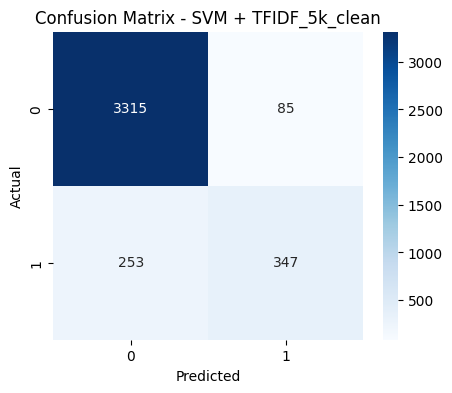

=== Model: Naive Bayes | Vectorizer: TFIDF_10k_clean ===
Accuracy : 0.8992
Precision: 0.8316
Recall   : 0.4117
F1-score : 0.5507
Confusion Matrix:
[[3350   50]
 [ 353  247]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      3400
           1       0.83      0.41      0.55       600

    accuracy                           0.90      4000
   macro avg       0.87      0.70      0.75      4000
weighted avg       0.89      0.90      0.88      4000





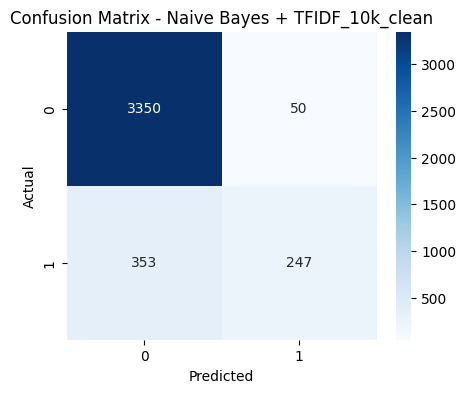

=== Model: Logistic Regression | Vectorizer: TFIDF_10k_clean ===
Accuracy : 0.9052
Precision: 0.8203
Recall   : 0.4717
F1-score : 0.5989
Confusion Matrix:
[[3338   62]
 [ 317  283]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      3400
           1       0.82      0.47      0.60       600

    accuracy                           0.91      4000
   macro avg       0.87      0.73      0.77      4000
weighted avg       0.90      0.91      0.89      4000





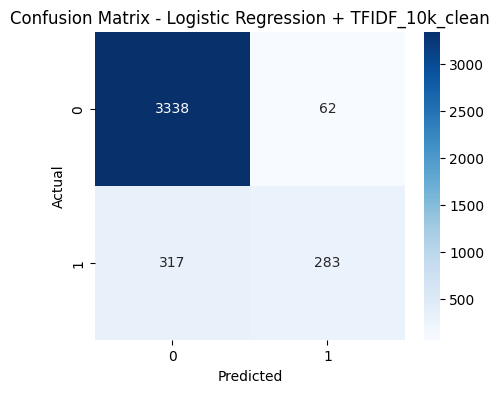

=== Model: SVM | Vectorizer: TFIDF_10k_clean ===
Accuracy : 0.9175
Precision: 0.8082
Recall   : 0.5900
F1-score : 0.6821
Confusion Matrix:
[[3316   84]
 [ 246  354]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3400
           1       0.81      0.59      0.68       600

    accuracy                           0.92      4000
   macro avg       0.87      0.78      0.82      4000
weighted avg       0.91      0.92      0.91      4000





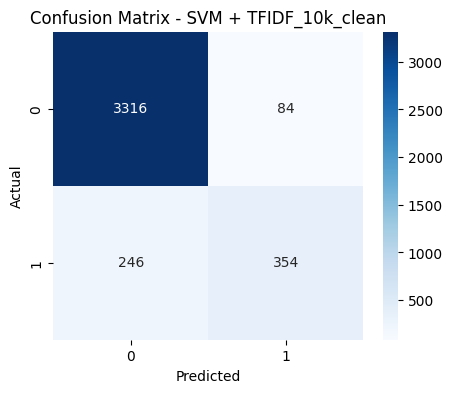

=== Model: Naive Bayes | Vectorizer: Bow_5k_clean ===
Accuracy : 0.8995
Precision: 0.6495
Recall   : 0.7167
F1-score : 0.6815
Confusion Matrix:
[[3168  232]
 [ 170  430]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      3400
           1       0.65      0.72      0.68       600

    accuracy                           0.90      4000
   macro avg       0.80      0.82      0.81      4000
weighted avg       0.90      0.90      0.90      4000





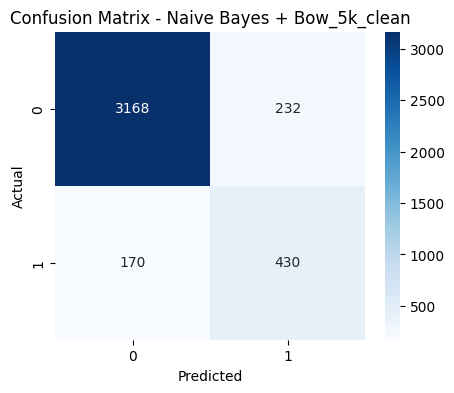

=== Model: Logistic Regression | Vectorizer: Bow_5k_clean ===
Accuracy : 0.9097
Precision: 0.7812
Recall   : 0.5533
F1-score : 0.6478
Confusion Matrix:
[[3307   93]
 [ 268  332]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3400
           1       0.78      0.55      0.65       600

    accuracy                           0.91      4000
   macro avg       0.85      0.76      0.80      4000
weighted avg       0.90      0.91      0.90      4000





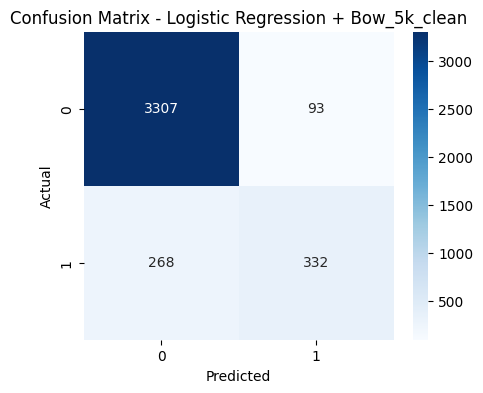

=== Model: SVM | Vectorizer: Bow_5k_clean ===
Accuracy : 0.9055
Precision: 0.7211
Recall   : 0.6033
F1-score : 0.6570
Confusion Matrix:
[[3260  140]
 [ 238  362]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      3400
           1       0.72      0.60      0.66       600

    accuracy                           0.91      4000
   macro avg       0.83      0.78      0.80      4000
weighted avg       0.90      0.91      0.90      4000





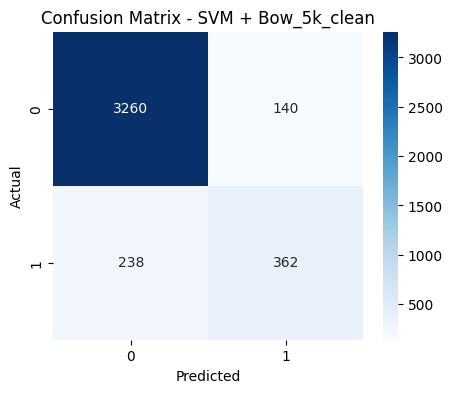

=== Model: Naive Bayes | Vectorizer: Bow_10k_clean ===
Accuracy : 0.9018
Precision: 0.6552
Recall   : 0.7283
F1-score : 0.6898
Confusion Matrix:
[[3170  230]
 [ 163  437]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      3400
           1       0.66      0.73      0.69       600

    accuracy                           0.90      4000
   macro avg       0.80      0.83      0.82      4000
weighted avg       0.91      0.90      0.90      4000





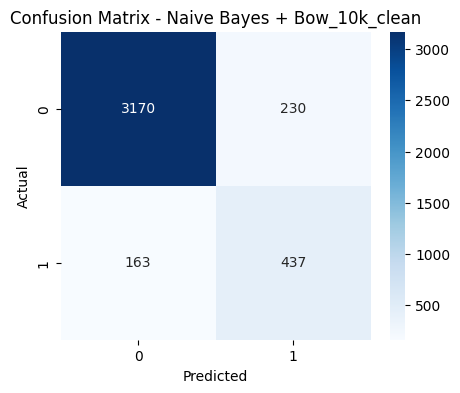

=== Model: Logistic Regression | Vectorizer: Bow_10k_clean ===
Accuracy : 0.9107
Precision: 0.7872
Recall   : 0.5550
F1-score : 0.6510
Confusion Matrix:
[[3310   90]
 [ 267  333]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3400
           1       0.79      0.56      0.65       600

    accuracy                           0.91      4000
   macro avg       0.86      0.76      0.80      4000
weighted avg       0.90      0.91      0.90      4000





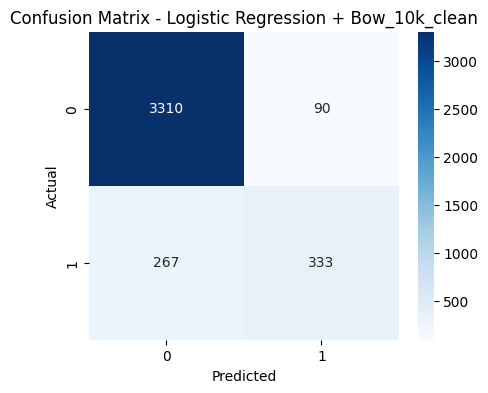

=== Model: SVM | Vectorizer: Bow_10k_clean ===
Accuracy : 0.9045
Precision: 0.7129
Recall   : 0.6083
F1-score : 0.6565
Confusion Matrix:
[[3253  147]
 [ 235  365]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      3400
           1       0.71      0.61      0.66       600

    accuracy                           0.90      4000
   macro avg       0.82      0.78      0.80      4000
weighted avg       0.90      0.90      0.90      4000





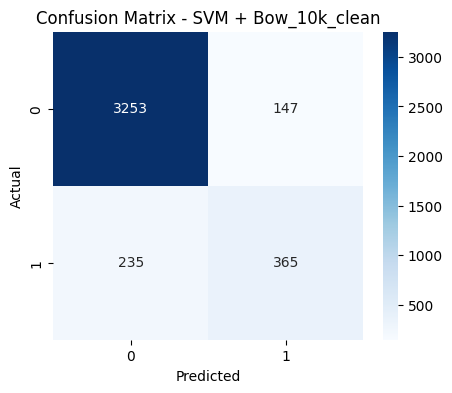

=== Best Accuracy ===
Vectorizer: TFIDF_10k_clean
Model: SVM
Accuracy: 0.9175
=== Best model for class 1 (Kinh tế/Kinh doanh) ===
Vectorizer: Bow_10k_clean
Model: Naive Bayes
Accuracy: 0.9018
Precision: 0.6552
Recall: 0.7283
F1: 0.6898


In [34]:
results_1 = run_experiment(vectorizers, models, X_train, X_test, y_train, y_test)
best_acc_1 = get_best_accuracy(results_1)
best_f1_1 = get_best_f1_label1(results_1)

### Hướng 2.1: Xử lý mất cân bằng lớp (Class weight)
```
1. Lý do thử
Dataset lệch 85% vs 15%
Model dễ bias về class 0
Recall class 1 thấp
```

In [37]:
vectorizers = {
    "Bow": CountVectorizer(),
    "TF-IDF": TfidfVectorizer()
}

models = {
    "Naive Bayes": MultinomialNB(),  # NB không hỗ trợ class_weight trực tiếp
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM": SVC(kernel="linear", class_weight="balanced")
}

=== Model: Naive Bayes | Vectorizer: Bow ===
Accuracy : 0.9113
Precision: 0.7316
Recall   : 0.6450
F1-score : 0.6856
Confusion Matrix:
[[3258  142]
 [ 213  387]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3400
           1       0.73      0.65      0.69       600

    accuracy                           0.91      4000
   macro avg       0.84      0.80      0.82      4000
weighted avg       0.91      0.91      0.91      4000





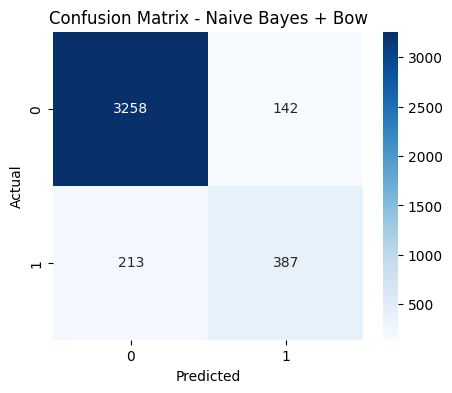

=== Model: Logistic Regression | Vectorizer: Bow ===
Accuracy : 0.9032
Precision: 0.6494
Recall   : 0.7717
F1-score : 0.7053
Confusion Matrix:
[[3150  250]
 [ 137  463]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      3400
           1       0.65      0.77      0.71       600

    accuracy                           0.90      4000
   macro avg       0.80      0.85      0.82      4000
weighted avg       0.91      0.90      0.91      4000





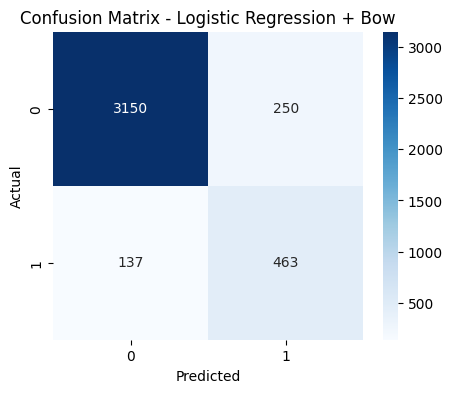

=== Model: SVM | Vectorizer: Bow ===
Accuracy : 0.8905
Precision: 0.6184
Recall   : 0.7050
F1-score : 0.6589
Confusion Matrix:
[[3139  261]
 [ 177  423]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      3400
           1       0.62      0.70      0.66       600

    accuracy                           0.89      4000
   macro avg       0.78      0.81      0.80      4000
weighted avg       0.90      0.89      0.89      4000





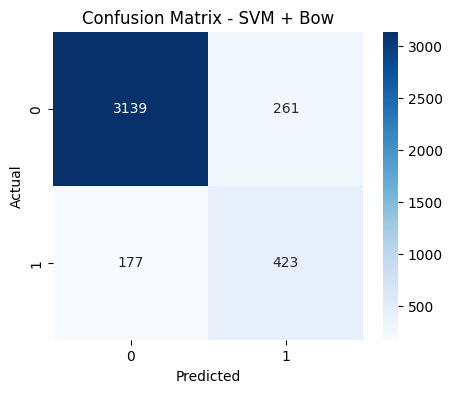

=== Model: Naive Bayes | Vectorizer: TF-IDF ===
Accuracy : 0.8782
Precision: 0.9007
Recall   : 0.2117
F1-score : 0.3428
Confusion Matrix:
[[3386   14]
 [ 473  127]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      3400
           1       0.90      0.21      0.34       600

    accuracy                           0.88      4000
   macro avg       0.89      0.60      0.64      4000
weighted avg       0.88      0.88      0.84      4000





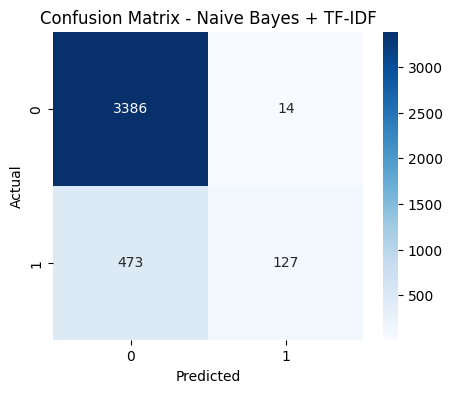

=== Model: Logistic Regression | Vectorizer: TF-IDF ===
Accuracy : 0.8935
Precision: 0.6115
Recall   : 0.7950
F1-score : 0.6913
Confusion Matrix:
[[3097  303]
 [ 123  477]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      3400
           1       0.61      0.80      0.69       600

    accuracy                           0.89      4000
   macro avg       0.79      0.85      0.81      4000
weighted avg       0.91      0.89      0.90      4000





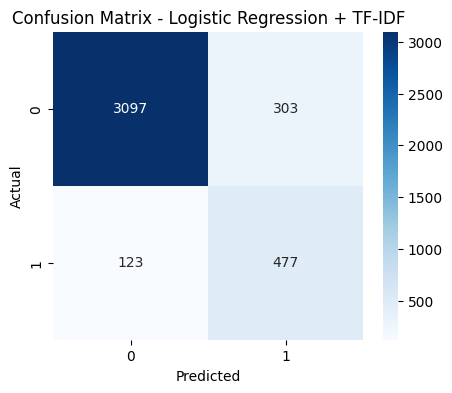

=== Model: SVM | Vectorizer: TF-IDF ===
Accuracy : 0.8950
Precision: 0.6157
Recall   : 0.7983
F1-score : 0.6952
Confusion Matrix:
[[3101  299]
 [ 121  479]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      3400
           1       0.62      0.80      0.70       600

    accuracy                           0.90      4000
   macro avg       0.79      0.86      0.82      4000
weighted avg       0.91      0.90      0.90      4000





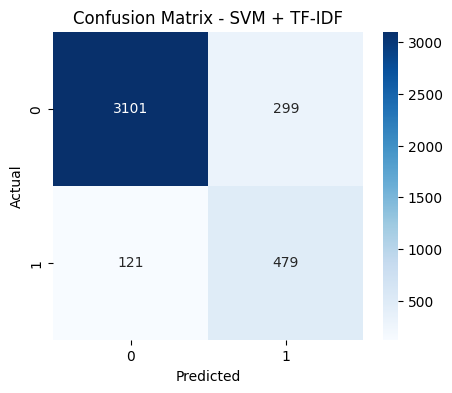

=== Best Accuracy ===
Vectorizer: Bow
Model: Naive Bayes
Accuracy: 0.9113
=== Best model for class 1 (Kinh tế/Kinh doanh) ===
Vectorizer: Bow
Model: Logistic Regression
Accuracy: 0.9032
Precision: 0.6494
Recall: 0.7717
F1: 0.7053


In [38]:
results_2_1 = run_experiment(vectorizers, models, X_train, X_test, y_train, y_test)
best_acc_2_1 = get_best_accuracy(results_2_1)
best_f1_2_1 = get_best_f1_label1(results_2_1)

### Hướng 2.2: Xử lý mất cân bằng lớp (Resampling)

In [39]:
from imblearn.over_sampling import RandomOverSampler

# Oversampler
ros = RandomOverSampler(random_state=42)

In [40]:
vectorizers = {
    "Bow": CountVectorizer(),
    "TF-IDF": TfidfVectorizer()
}

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel="linear")
}


After Oversampling (Bow):
Class 0: 13600
Class 1: 13600
Bow + Naive Bayes
Acc: 0.8702 | F1: 0.6579 | Precision: 0.5442 | Recall: 0.8317


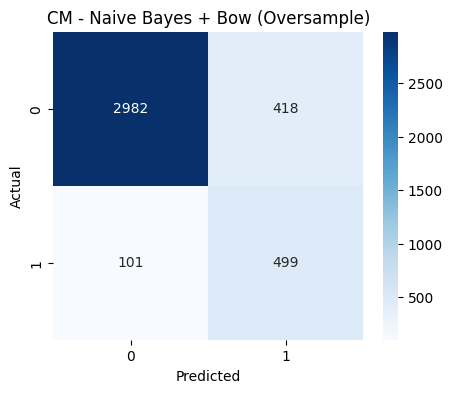

Bow + Logistic Regression
Acc: 0.9012 | F1: 0.6940 | Precision: 0.6483 | Recall: 0.7467


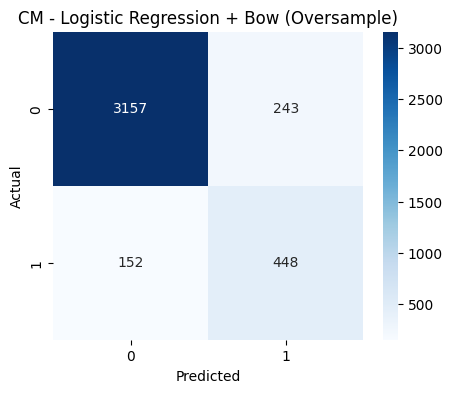

Bow + SVM
Acc: 0.8905 | F1: 0.6518 | Precision: 0.6231 | Recall: 0.6833


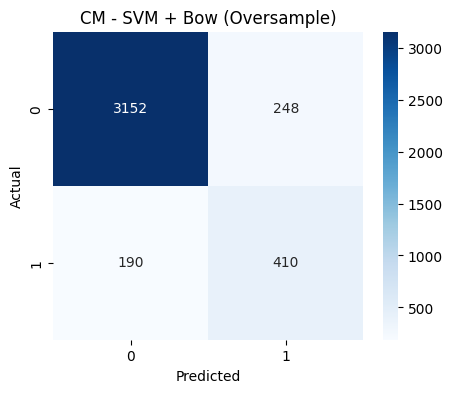


After Oversampling (TF-IDF):
Class 0: 13600
Class 1: 13600
TF-IDF + Naive Bayes
Acc: 0.8618 | F1: 0.6466 | Precision: 0.5244 | Recall: 0.8433


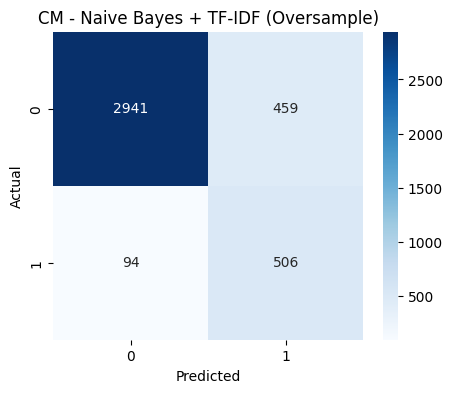

TF-IDF + Logistic Regression
Acc: 0.8955 | F1: 0.6931 | Precision: 0.6194 | Recall: 0.7867


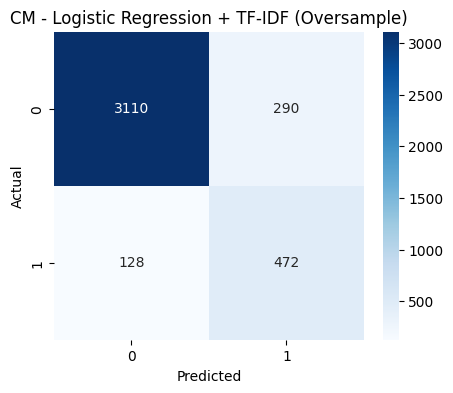

TF-IDF + SVM
Acc: 0.9012 | F1: 0.7014 | Precision: 0.6418 | Recall: 0.7733


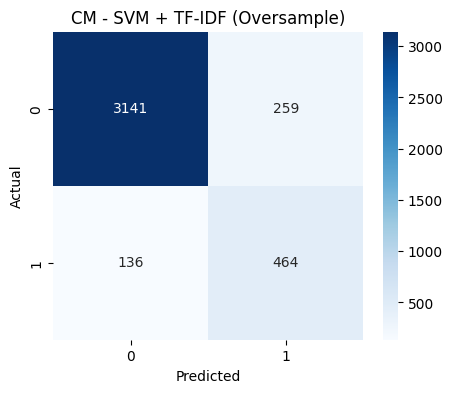

In [41]:
results_2_2 = []

for vec_name, vectorizer in vectorizers.items():

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Oversampling 
    X_res, y_res = ros.fit_resample(X_train_vec, y_train)

    print(f"\nAfter Oversampling ({vec_name}):")
    print("Class 0:", sum(y_res == 0))
    print("Class 1:", sum(y_res == 1))

    for model_name, model in models.items():

        # Train
        model.fit(X_res, y_res)

        # Predict
        y_pred = model.predict(X_test_vec)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)

        print(f"{vec_name} + {model_name}")
        print(f"Acc: {acc:.4f} | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'CM - {model_name} + {vec_name} (Oversample)')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

        results_2_2.append({
            "vectorizer": vec_name,
            "model": model_name,
            "accuracy": acc,
            "f1": f1,
            "precision": precision,
            "recall": recall
        })

In [42]:
best_acc_2_2 = get_best_accuracy(results_2_2)
best_f1_2_2 = get_best_f1_label1(results_2_2)

=== Best Accuracy ===
Vectorizer: Bow
Model: Logistic Regression
Accuracy: 0.9012
=== Best model for class 1 (Kinh tế/Kinh doanh) ===
Vectorizer: TF-IDF
Model: SVM
Accuracy: 0.9012
Precision: 0.6418
Recall: 0.7733
F1: 0.7014


### Hướng 4: Thử n-gram
```Unigram mất ngữ cảnh
Bigram giúp hiểu cụm từ:
"thị trường"
"giá vàng"
"lãi suất"
```

In [72]:
vectorizers = {
    "Bow_Bigram": CountVectorizer(ngram_range=(1,2)),
    "Bow_TriGram": CountVectorizer(ngram_range=(1,3)),
    "TFIDF_Bigram": TfidfVectorizer(ngram_range=(1,2)),
    "TFIDF_TriGram": TfidfVectorizer(ngram_range=(1,3))
}

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel="linear")
}

=== Model: Naive Bayes | Vectorizer: Bow_Bigram ===
Accuracy : 0.9145
Precision: 0.8131
Recall   : 0.5583
F1-score : 0.6621
Confusion Matrix:
[[3323   77]
 [ 265  335]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3400
           1       0.81      0.56      0.66       600

    accuracy                           0.91      4000
   macro avg       0.87      0.77      0.81      4000
weighted avg       0.91      0.91      0.91      4000





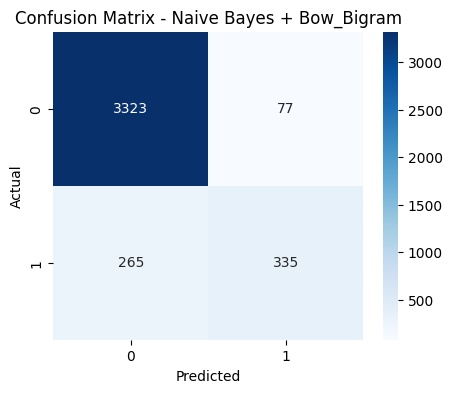

=== Model: Logistic Regression | Vectorizer: Bow_Bigram ===
Accuracy : 0.9145
Precision: 0.8146
Recall   : 0.5567
F1-score : 0.6614
Confusion Matrix:
[[3324   76]
 [ 266  334]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3400
           1       0.81      0.56      0.66       600

    accuracy                           0.91      4000
   macro avg       0.87      0.77      0.81      4000
weighted avg       0.91      0.91      0.91      4000





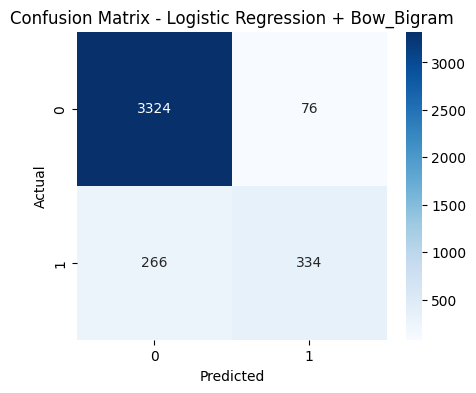

=== Model: SVM | Vectorizer: Bow_Bigram ===
Accuracy : 0.9167
Precision: 0.7834
Recall   : 0.6150
F1-score : 0.6891
Confusion Matrix:
[[3298  102]
 [ 231  369]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3400
           1       0.78      0.61      0.69       600

    accuracy                           0.92      4000
   macro avg       0.86      0.79      0.82      4000
weighted avg       0.91      0.92      0.91      4000





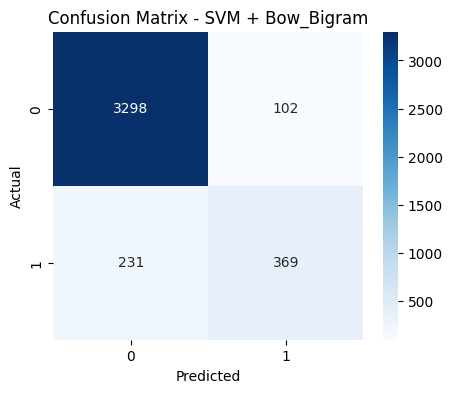

=== Model: Naive Bayes | Vectorizer: Bow_TriGram ===
Accuracy : 0.9123
Precision: 0.8430
Recall   : 0.5100
F1-score : 0.6355
Confusion Matrix:
[[3343   57]
 [ 294  306]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      3400
           1       0.84      0.51      0.64       600

    accuracy                           0.91      4000
   macro avg       0.88      0.75      0.79      4000
weighted avg       0.91      0.91      0.90      4000





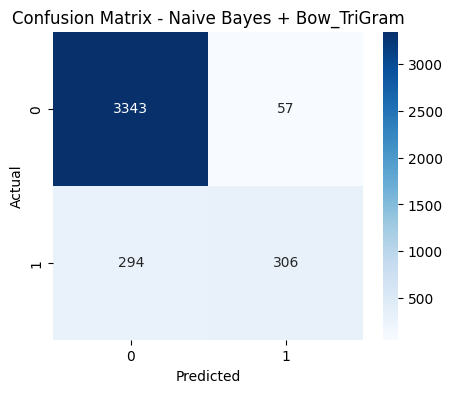

=== Model: Logistic Regression | Vectorizer: Bow_TriGram ===
Accuracy : 0.9105
Precision: 0.8184
Recall   : 0.5183
F1-score : 0.6347
Confusion Matrix:
[[3331   69]
 [ 289  311]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      3400
           1       0.82      0.52      0.63       600

    accuracy                           0.91      4000
   macro avg       0.87      0.75      0.79      4000
weighted avg       0.90      0.91      0.90      4000





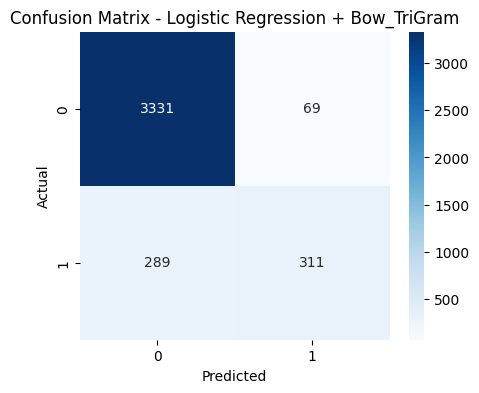

=== Model: SVM | Vectorizer: Bow_TriGram ===
Accuracy : 0.9145
Precision: 0.7879
Recall   : 0.5883
F1-score : 0.6737
Confusion Matrix:
[[3305   95]
 [ 247  353]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3400
           1       0.79      0.59      0.67       600

    accuracy                           0.91      4000
   macro avg       0.86      0.78      0.81      4000
weighted avg       0.91      0.91      0.91      4000





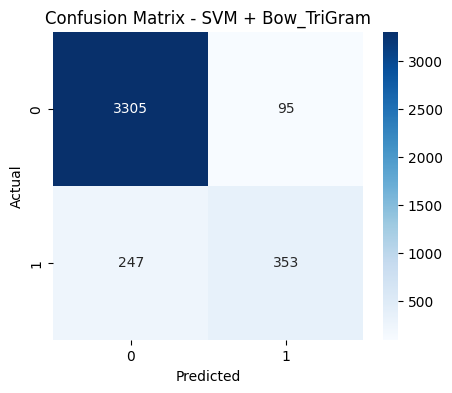

=== Model: Naive Bayes | Vectorizer: TFIDF_Bigram ===
Accuracy : 0.8692
Precision: 0.9529
Recall   : 0.1350
F1-score : 0.2365
Confusion Matrix:
[[3396    4]
 [ 519   81]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      3400
           1       0.95      0.14      0.24       600

    accuracy                           0.87      4000
   macro avg       0.91      0.57      0.58      4000
weighted avg       0.88      0.87      0.82      4000





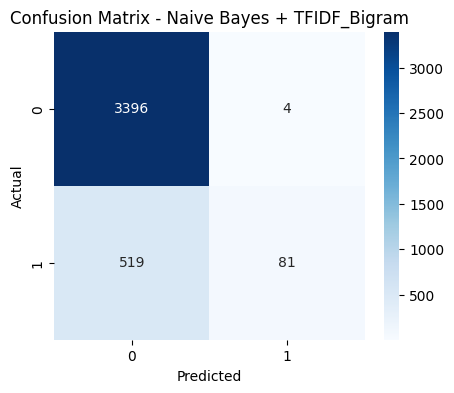

=== Model: Logistic Regression | Vectorizer: TFIDF_Bigram ===
Accuracy : 0.9018
Precision: 0.8017
Recall   : 0.4583
F1-score : 0.5832
Confusion Matrix:
[[3332   68]
 [ 325  275]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      3400
           1       0.80      0.46      0.58       600

    accuracy                           0.90      4000
   macro avg       0.86      0.72      0.76      4000
weighted avg       0.89      0.90      0.89      4000





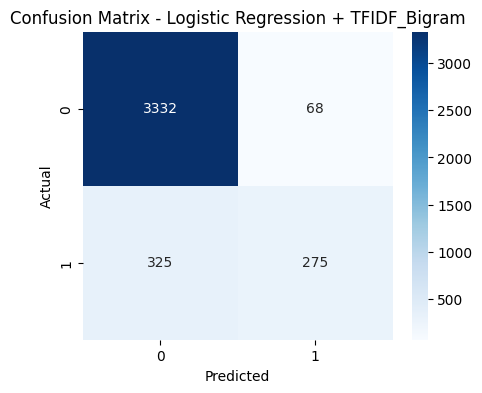

=== Model: SVM | Vectorizer: TFIDF_Bigram ===
Accuracy : 0.9205
Precision: 0.7798
Recall   : 0.6550
F1-score : 0.7120
Confusion Matrix:
[[3289  111]
 [ 207  393]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      3400
           1       0.78      0.66      0.71       600

    accuracy                           0.92      4000
   macro avg       0.86      0.81      0.83      4000
weighted avg       0.92      0.92      0.92      4000





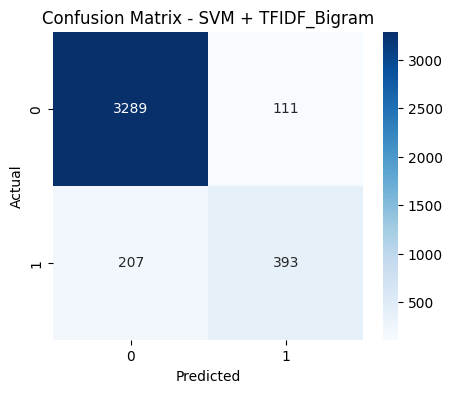

=== Model: Naive Bayes | Vectorizer: TFIDF_TriGram ===
Accuracy : 0.8645
Precision: 0.9394
Recall   : 0.1033
F1-score : 0.1862
Confusion Matrix:
[[3396    4]
 [ 538   62]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93      3400
           1       0.94      0.10      0.19       600

    accuracy                           0.86      4000
   macro avg       0.90      0.55      0.56      4000
weighted avg       0.87      0.86      0.82      4000





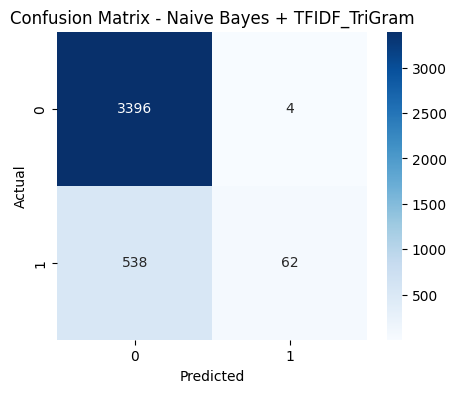

=== Model: Logistic Regression | Vectorizer: TFIDF_TriGram ===
Accuracy : 0.9008
Precision: 0.7812
Recall   : 0.4700
F1-score : 0.5869
Confusion Matrix:
[[3321   79]
 [ 318  282]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      3400
           1       0.78      0.47      0.59       600

    accuracy                           0.90      4000
   macro avg       0.85      0.72      0.77      4000
weighted avg       0.89      0.90      0.89      4000





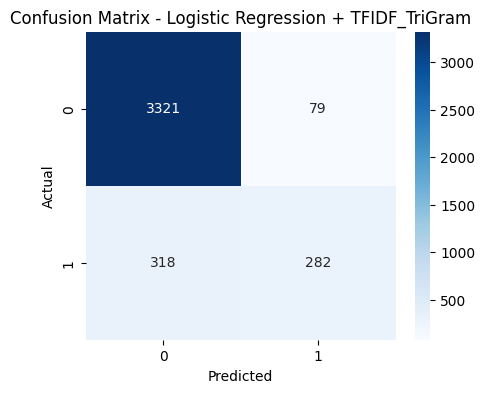

=== Model: SVM | Vectorizer: TFIDF_TriGram ===
Accuracy : 0.9173
Precision: 0.7552
Recall   : 0.6633
F1-score : 0.7063
Confusion Matrix:
[[3271  129]
 [ 202  398]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3400
           1       0.76      0.66      0.71       600

    accuracy                           0.92      4000
   macro avg       0.85      0.81      0.83      4000
weighted avg       0.91      0.92      0.92      4000





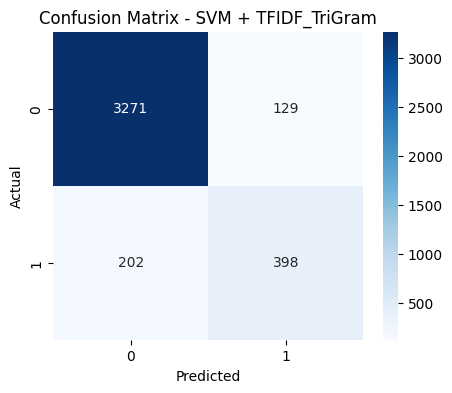

=== Best Accuracy ===
Vectorizer: TFIDF_Bigram
Model: SVM
Accuracy: 0.9205
=== Best model for class 1 (Kinh tế/Kinh doanh) ===
Vectorizer: TFIDF_Bigram
Model: SVM
Accuracy: 0.9205
Precision: 0.7798
Recall: 0.6550
F1: 0.7120


In [73]:
results_4 = run_experiment(vectorizers, models, X_train, X_test, y_train, y_test)
best_acc_4 = get_best_accuracy(results_4)
best_f1_4 = get_best_f1_label1(results_4)

### Hướng 6: Điều chỉnh tham số mô hình
```
1. Lý do thử
Model mặc định chưa tối ưu
Tuning giúp cải thiện hiệu suất
```

In [74]:
vectorizers = {
    "Bow": CountVectorizer(),
    "TF-IDF": TfidfVectorizer()
}

models = {
    "Naive Bayes": MultinomialNB(alpha=0.5),
    "Logistic Regression": LogisticRegression(C=0.5, max_iter=2000),
    "SVM": SVC(kernel='linear', C=0.5)
}

=== Model: Naive Bayes | Vectorizer: Bow ===
Accuracy : 0.9125
Precision: 0.7126
Recall   : 0.6983
F1-score : 0.7054
Confusion Matrix:
[[3231  169]
 [ 181  419]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      3400
           1       0.71      0.70      0.71       600

    accuracy                           0.91      4000
   macro avg       0.83      0.82      0.83      4000
weighted avg       0.91      0.91      0.91      4000





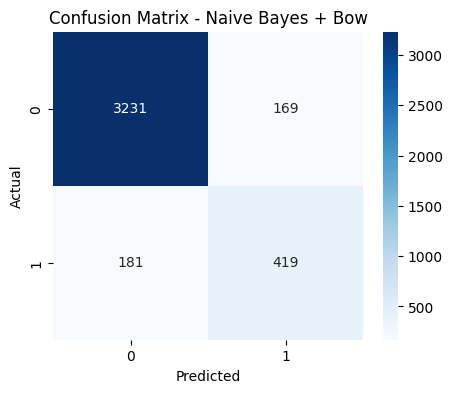

=== Model: Logistic Regression | Vectorizer: Bow ===
Accuracy : 0.9097
Precision: 0.7995
Recall   : 0.5317
F1-score : 0.6386
Confusion Matrix:
[[3320   80]
 [ 281  319]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      3400
           1       0.80      0.53      0.64       600

    accuracy                           0.91      4000
   macro avg       0.86      0.75      0.79      4000
weighted avg       0.90      0.91      0.90      4000





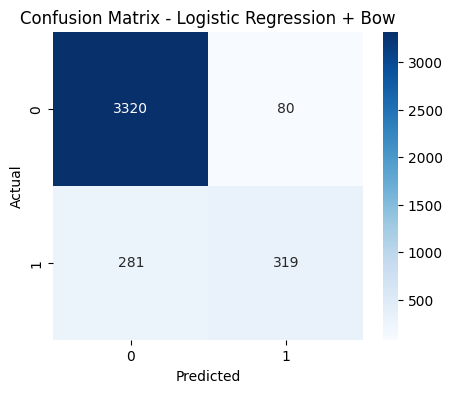

=== Model: SVM | Vectorizer: Bow ===
Accuracy : 0.9125
Precision: 0.7451
Recall   : 0.6333
F1-score : 0.6847
Confusion Matrix:
[[3270  130]
 [ 220  380]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3400
           1       0.75      0.63      0.68       600

    accuracy                           0.91      4000
   macro avg       0.84      0.80      0.82      4000
weighted avg       0.91      0.91      0.91      4000





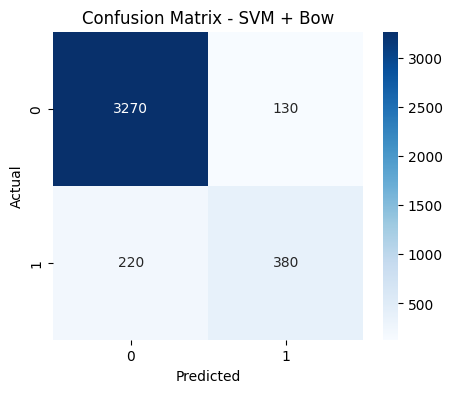

=== Model: Naive Bayes | Vectorizer: TF-IDF ===
Accuracy : 0.8972
Precision: 0.8735
Recall   : 0.3683
F1-score : 0.5182
Confusion Matrix:
[[3368   32]
 [ 379  221]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      3400
           1       0.87      0.37      0.52       600

    accuracy                           0.90      4000
   macro avg       0.89      0.68      0.73      4000
weighted avg       0.90      0.90      0.88      4000





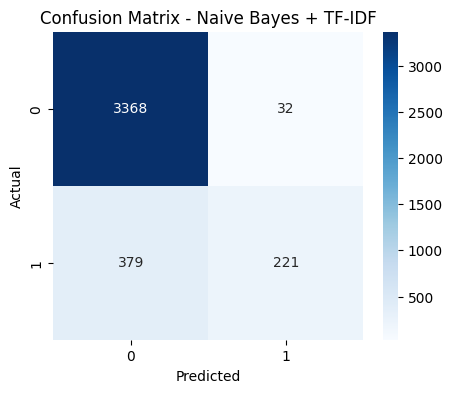

=== Model: Logistic Regression | Vectorizer: TF-IDF ===
Accuracy : 0.8942
Precision: 0.8365
Recall   : 0.3667
F1-score : 0.5098
Confusion Matrix:
[[3357   43]
 [ 380  220]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      3400
           1       0.84      0.37      0.51       600

    accuracy                           0.89      4000
   macro avg       0.87      0.68      0.73      4000
weighted avg       0.89      0.89      0.88      4000





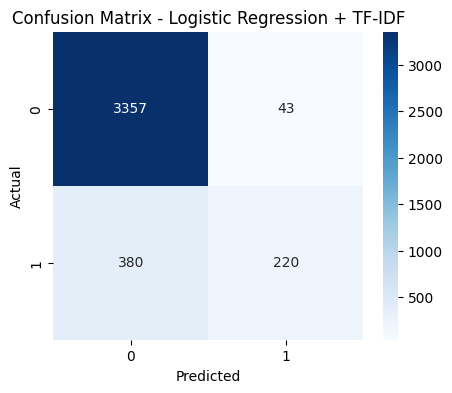

=== Model: SVM | Vectorizer: TF-IDF ===
Accuracy : 0.9107
Precision: 0.8172
Recall   : 0.5217
F1-score : 0.6368
Confusion Matrix:
[[3330   70]
 [ 287  313]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      3400
           1       0.82      0.52      0.64       600

    accuracy                           0.91      4000
   macro avg       0.87      0.75      0.79      4000
weighted avg       0.91      0.91      0.90      4000





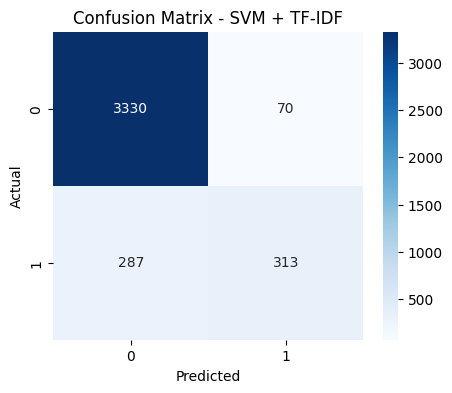

=== Best Accuracy ===
Vectorizer: Bow
Model: Naive Bayes
Accuracy: 0.9125
=== Best model for class 1 (Kinh tế/Kinh doanh) ===
Vectorizer: Bow
Model: Naive Bayes
Accuracy: 0.9125
Precision: 0.7126
Recall: 0.6983
F1: 0.7054


In [75]:
results_6 = run_experiment(vectorizers, models, X_train, X_test, y_train, y_test)
best_acc_6 = get_best_accuracy(results_6)
best_f1_6 = get_best_f1_label1(results_6)

### Hướng 7: Cross Validation (Stradified K-Fold)

In [76]:
vectorizers = {
    "Bow": CountVectorizer(),
    "TF-IDF": TfidfVectorizer()
}

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel="linear")
}

In [31]:
#Stratified K-Fold
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [82]:
from sklearn.metrics import classification_report
from sklearn.base import clone

results_7 = []

texts = np.array(texts)
label = np.array(label)

for vec_name, vectorizer in vectorizers.items():
    
    for model_name, model in models.items():
        
        best_f1 = -1
        best_result = None
        
        for fold, (train_index, test_index) in enumerate(skf.split(texts, label), 1):
            X_train, X_test = texts[train_index], texts[test_index]
            y_train, y_test = label[train_index], label[test_index]

            # Clone để tránh overwrite model/vectorizer
            vec = clone(vectorizer)
            clf = clone(model)

            # Vectorize
            X_train_vec = vec.fit_transform(X_train)
            X_test_vec = vec.transform(X_test)

            # Train
            clf.fit(X_train_vec, y_train)

            # Predict
            y_pred = clf.predict(X_test_vec)

            # Metrics
            f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

            # Lưu fold tốt nhất
            if f1 > best_f1:
                best_f1 = f1
                best_result = {
                    "fold": fold,
                    "y_test": y_test,
                    "y_pred": y_pred,
                    "accuracy": accuracy_score(y_test, y_pred),
                    "precision": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
                    "recall": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
                    "f1": f1,
                    "cm": confusion_matrix(y_test, y_pred)
                }

        # In kết quả tốt nhất
        print(f"\n=== BEST Fold for {model_name} + {vec_name} ===")
        print(f"Fold: {best_result['fold']}")
        print(f"Accuracy : {best_result['accuracy']:.4f}")
        print(f"Precision: {best_result['precision']:.4f}")
        print(f"Recall   : {best_result['recall']:.4f}")
        print(f"F1-score : {best_result['f1']:.4f}")

        print("\nConfusion Matrix:")
        print(best_result["cm"])

        print("\nClassification Report:")
        print(classification_report(best_result["y_test"], best_result["y_pred"], zero_division=0))

        # Lưu kết quả
        results_7.append({
            "vectorizer": vec_name,
            "model": model_name,
            "best_fold": best_result["fold"],
            "accuracy": best_result["accuracy"],
            "precision": best_result["precision"],
            "recall": best_result["recall"],
            "f1": best_result["f1"]
        })


=== BEST Fold for Naive Bayes + Bow ===
Fold: 4
Accuracy : 0.9230
Precision: 0.7897
Recall   : 0.6633
F1-score : 0.7210

Confusion Matrix:
[[3294  106]
 [ 202  398]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      3400
           1       0.79      0.66      0.72       600

    accuracy                           0.92      4000
   macro avg       0.87      0.82      0.84      4000
weighted avg       0.92      0.92      0.92      4000


=== BEST Fold for Logistic Regression + Bow ===
Fold: 4
Accuracy : 0.9135
Precision: 0.7913
Recall   : 0.5750
F1-score : 0.6660

Confusion Matrix:
[[3309   91]
 [ 255  345]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      3400
           1       0.79      0.57      0.67       600

    accuracy                           0.91      4000
   macro avg       0.86      0.77      0.81      4000
weighted av

In [83]:
best_acc_7 = get_best_accuracy(results_7)
best_f1_7 = get_best_f1_label1(results_7)

=== Best Accuracy ===
Vectorizer: Bow
Model: Naive Bayes
Accuracy: 0.9230
=== Best model for class 1 (Kinh tế/Kinh doanh) ===
Vectorizer: Bow
Model: Naive Bayes
Accuracy: 0.9230
Precision: 0.7897
Recall: 0.6633
F1: 0.7210


### Hướng 5: Thử đầu vào khác
```
Content
```

In [9]:
import random

random.seed(42)

# Lọc dữ liệu không rỗng
data_label_1 = [i for i in data if i["label"] == 1 and i.get("content")]
data_label_0 = [i for i in data if i["label"] == 0 and i.get("content")]

# Lấy mẫu
sample_label_1 = random.sample(data_label_1, 3000)
sample_label_0 = random.sample(data_label_0, 17000)

# Kết hợp và xáo trộn
sample_dataset = sample_label_1 + sample_label_0
random.shuffle(sample_dataset)

# Kiểm tra tỉ lệ
count_label_1 = sum(1 for i in sample_dataset if i["label"] == 1)
count_label_0 = sum(1 for i in sample_dataset if i["label"] == 0)
ratio_label_1 = count_label_1 / len(sample_dataset)
ratio_label_0 = count_label_0 / len(sample_dataset)

print(f"Tổng số mẫu: {len(sample_dataset)}")
print(f"Số mẫu label 1: {count_label_1} ({ratio_label_1:.2%})")
print(f"Số mẫu label 0: {count_label_0} ({ratio_label_0:.2%})")

Tổng số mẫu: 20000
Số mẫu label 1: 3000 (15.00%)
Số mẫu label 0: 17000 (85.00%)


In [10]:
# Tiền xử lý trả về chuỗi sạch
texts = [item["content"] for item in sample_dataset]
texts_clean = preprocess_texts_vn(texts, stopwords=vietnamese_stopwords)

In [11]:
texts = texts_clean
label = [i["label"] for i in sample_dataset]

print(texts[8])
print(label[8])
print(len(texts))
print(len(label))

một quan_chức dpr hai công_dân anh andrew hill dylan healy buộc_tội lính đánh thuê thực_hiện khóa huấn_luyện khủng_bố chúng_tra hai công_dân anh dylan healy andrew hill họ cáo_buộc khoản tương_lính đánh thuê kết_án cnn dẫn quan_chức dpr nói dpr kết_án tử_hình công_dân anh aiden aslin shaun pinner công_dân morocco_cáo_buộc lính đánh thuê quân_đội ukraine luật_sư pinner kháng_cáo khoan_hồng thân_chủ lãnh_án tử_hình andrew_hill xuất_hiện video phát_sóng truyền_hình nga bao_video hồi tiêu_đề độc_quyền hành_quyết hill phục_vụ trung_đoàn lancaster quân_đội anh ông xuất_hiện đầu truyền_thông nga hồi tình_trạng thương nặng tôi nhà_quê_hương gia_đình đứa tôi tôi thật guardian dẫn hill video thời trong dylan healy tư_tình_nguyện_viên hỗ_trợ nhân_đạo ukraine tổ_chức nhân_đạo nào dylan healy công_dân anh paul_urey bắt hỗ_trợ nhân_đạo thành_phố zaporizhzhia miền nam ukraine
0
20000
20000


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    texts, label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

import numpy as np

y_train = np.array(y_train)
y_test = np.array(y_test)

print(len(X_train))
print( len(X_test))
print(len(y_train))
print(len(y_test))
print(sum(y_test == 0), sum(y_test == 1))



16000
4000
16000
4000
3400 600


In [88]:
vectorizers = {
    "Bow": CountVectorizer(),
    "TF-IDF": TfidfVectorizer()
}

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter = 1000),
    "SVM": SVC(kernel="linear")
}

=== Model: Naive Bayes | Vectorizer: Bow ===
Accuracy : 0.9293
Precision: 0.7321
Recall   : 0.8333
F1-score : 0.7794
Confusion Matrix:
[[3217  183]
 [ 100  500]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      3400
           1       0.73      0.83      0.78       600

    accuracy                           0.93      4000
   macro avg       0.85      0.89      0.87      4000
weighted avg       0.93      0.93      0.93      4000





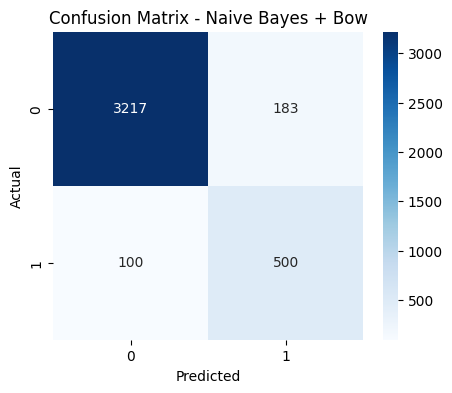

=== Model: Logistic Regression | Vectorizer: Bow ===
Accuracy : 0.9285
Precision: 0.7929
Recall   : 0.7083
F1-score : 0.7482
Confusion Matrix:
[[3289  111]
 [ 175  425]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3400
           1       0.79      0.71      0.75       600

    accuracy                           0.93      4000
   macro avg       0.87      0.84      0.85      4000
weighted avg       0.93      0.93      0.93      4000





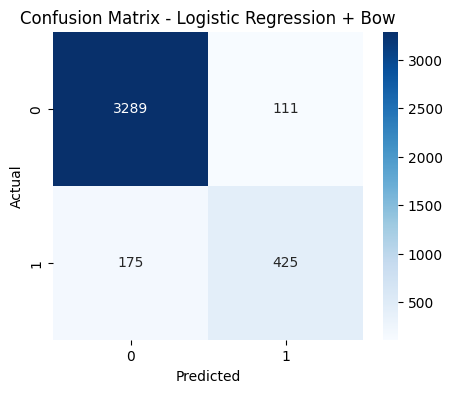

=== Model: SVM | Vectorizer: Bow ===
Accuracy : 0.9175
Precision: 0.7296
Recall   : 0.7150
F1-score : 0.7222
Confusion Matrix:
[[3241  159]
 [ 171  429]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      3400
           1       0.73      0.71      0.72       600

    accuracy                           0.92      4000
   macro avg       0.84      0.83      0.84      4000
weighted avg       0.92      0.92      0.92      4000





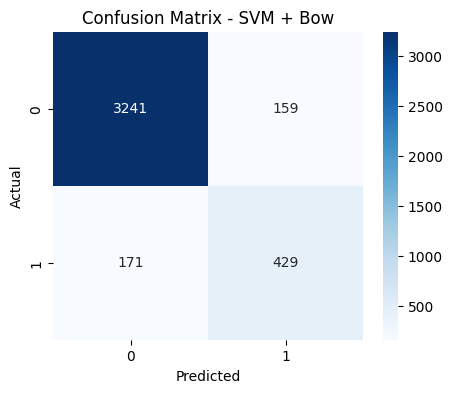

=== Model: Naive Bayes | Vectorizer: TF-IDF ===
Accuracy : 0.8685
Precision: 1.0000
Recall   : 0.1233
F1-score : 0.2196
Confusion Matrix:
[[3400    0]
 [ 526   74]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      3400
           1       1.00      0.12      0.22       600

    accuracy                           0.87      4000
   macro avg       0.93      0.56      0.57      4000
weighted avg       0.89      0.87      0.82      4000





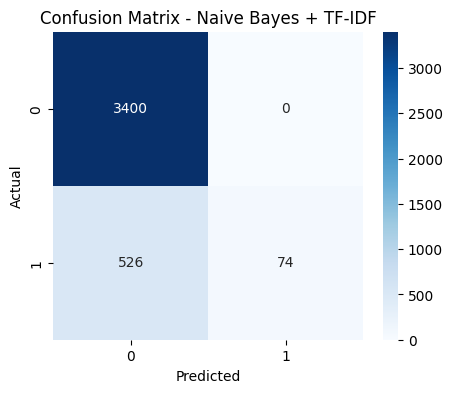

=== Model: Logistic Regression | Vectorizer: TF-IDF ===
Accuracy : 0.9370
Precision: 0.8625
Recall   : 0.6900
F1-score : 0.7667
Confusion Matrix:
[[3334   66]
 [ 186  414]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      3400
           1       0.86      0.69      0.77       600

    accuracy                           0.94      4000
   macro avg       0.90      0.84      0.87      4000
weighted avg       0.93      0.94      0.93      4000





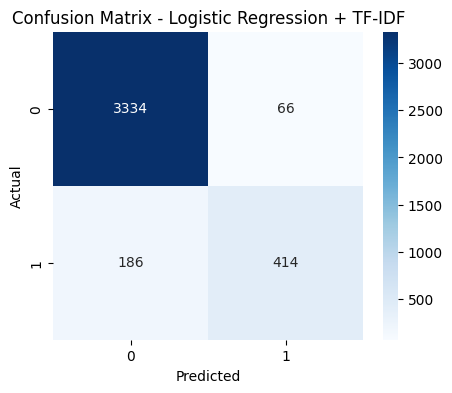

=== Model: SVM | Vectorizer: TF-IDF ===
Accuracy : 0.9420
Precision: 0.8552
Recall   : 0.7383
F1-score : 0.7925
Confusion Matrix:
[[3325   75]
 [ 157  443]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      3400
           1       0.86      0.74      0.79       600

    accuracy                           0.94      4000
   macro avg       0.91      0.86      0.88      4000
weighted avg       0.94      0.94      0.94      4000





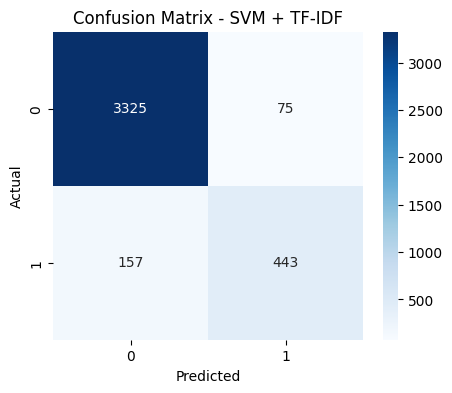

=== Best Accuracy ===
Vectorizer: TF-IDF
Model: SVM
Accuracy: 0.9420
=== Best model for class 1 (Kinh tế/Kinh doanh) ===
Vectorizer: TF-IDF
Model: SVM
Accuracy: 0.9420
Precision: 0.8552
Recall: 0.7383
F1: 0.7925


In [89]:
results_5 = run_experiment(vectorizers, models, X_train, X_test, y_train, y_test)
best_acc_5 = get_best_accuracy(results_5)
best_f1_5 = get_best_f1_label1(results_5)

### Kết hợp các hướng phù hợp tốt nhất
```
1. Giảm số lượng đặc trưng
2. Xử lý mất cân bằng lớp (class weight)
3. So sánh BoW và TF-IDF
4. Thử n-gram
5. Thử đầu vào khác nhau (full content)
6. Điều chỉnh tham số mô hình
7. Stradified K-fold
```

In [27]:
vec = CountVectorizer()
X_all = vec.fit_transform(texts)

vocab_size = len(vec.vocabulary_)
print("Total vocab size:", vocab_size)

Total vocab size: 285501


In [14]:
vectorizers = {
    "BoW": CountVectorizer(
        max_features=50000,
        min_df=3,
        max_df=0.85,
        ngram_range=(1,2)
    ),
    "TF-IDF": TfidfVectorizer(
        max_features=50000,
        min_df=3,
        max_df=0.85,
        ngram_range=(1,2)
    ),
    "TF-IDF_TriGram": TfidfVectorizer(
        max_features=20000,
        min_df=3,
        max_df=0.85,
        ngram_range=(1,3)
    )
}


models = {
    "Naive Bayes": MultinomialNB(alpha=0.5),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced', C=0.5),
    "SVM": SVC(kernel="linear", C=0.5, class_weight='balanced')
}

In [16]:
import numpy as np
texts = np.array(texts)
label = np.array(label)

In [18]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.base import clone

results = []

for vec_name, vectorizer in vectorizers.items():
    for model_name, model in models.items():
        fold_scores = []
        all_y_true = []
        all_y_pred = []

        for fold, (train_idx, test_idx) in enumerate(skf.split(texts, label), 1):
            X_train, X_test = texts[train_idx], texts[test_idx]
            y_train, y_test = label[train_idx], label[test_idx]

            vec = clone(vectorizer)
            clf = clone(model)

            # Vectorize
            X_train_vec = vec.fit_transform(X_train)
            X_test_vec = vec.transform(X_test)

            # Train & Predict
            clf.fit(X_train_vec, y_train)
            y_pred = clf.predict(X_test_vec)

            # Lưu kết quả fold
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
            precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
            recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)

            fold_scores.append({
                "accuracy": acc,
                "f1": f1,
                "precision": precision,
                "recall": recall
            })

            all_y_true.extend(y_test)
            all_y_pred.extend(y_pred)

        # Trung bình & std giữa các fold
        accs = [f["accuracy"] for f in fold_scores]
        f1s = [f["f1"] for f in fold_scores]
        precs = [f["precision"] for f in fold_scores]
        recs = [f["recall"] for f in fold_scores]

        print(f"\n=== {model_name} + {vec_name} ===")
        print(f"Accuracy : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
        print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
        print(f"Recall   : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
        print(f"F1       : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

        # Classification report tổng hợp
        print("\n--- Classification Report (All folds) ---")
        print(classification_report(all_y_true, all_y_pred, digits=4))

        results.append({
            "vectorizer": vec_name,
            "model": model_name,
            "accuracy_mean": np.mean(accs),
            "accuracy_std": np.std(accs),
            "precision_mean": np.mean(precs),
            "precision_std": np.std(precs),
            "recall_mean": np.mean(recs),
            "recall_std": np.std(recs),
            "f1_mean": np.mean(f1s),
            "f1_std": np.std(f1s)
        })

In [43]:
import pandas as pd

# Chuyển kết quả thành DataFrame
df_results = pd.DataFrame(results)

# Tạo cột "Model + Vectorizer"
df_results["Model + Vectorizer"] = df_results["model"] + " + " + df_results["vectorizer"]

# Chọn các cột cần hiển thị (dùng các giá trị trung bình)
df_display = df_results[[
    "Model + Vectorizer", 
    "accuracy_mean", 
    "precision_mean", 
    "recall_mean", 
    "f1_mean"
]]

# Đổi tên cột hiển thị cho đẹp
df_display = df_display.rename(columns={
    "accuracy_mean": "Accuracy",
    "precision_mean": "Precision",
    "recall_mean": "Recall",
    "f1_mean": "F1"
})

# Làm tròn các giá trị đến 4 chữ số thập phân
df_display = df_display.round(4)

# Hiển thị bảng Markdown
print(df_display.to_markdown(index=False))

| Model + Vectorizer                   |   Accuracy |   Precision |   Recall |     F1 |
|:-------------------------------------|-----------:|------------:|---------:|-------:|
| Naive Bayes + BoW                    |     0.9155 |      0.6606 |   0.898  | 0.7612 |
| Logistic Regression + BoW            |     0.9315 |      0.7651 |   0.7843 | 0.7744 |
| SVM + BoW                            |     0.9206 |      0.7366 |   0.7333 | 0.7348 |
| Naive Bayes + TF-IDF                 |     0.9382 |      0.8049 |   0.7757 | 0.7899 |
| Logistic Regression + TF-IDF         |     0.922  |      0.6843 |   0.891  | 0.774  |
| SVM + TF-IDF                         |     0.9251 |      0.6954 |   0.891  | 0.7811 |
| Naive Bayes + TF-IDF_TriGram         |     0.932  |      0.7451 |   0.8313 | 0.7858 |
| Logistic Regression + TF-IDF_TriGram |     0.9211 |      0.6808 |   0.8927 | 0.7724 |
| SVM + TF-IDF_TriGram                 |     0.9227 |      0.6856 |   0.8953 | 0.7765 |


In [45]:
def get_best_accuracy(results):
    # Lấy kết quả có accuracy_mean cao nhất
    best_acc = max(results, key=lambda x: x['accuracy_mean'])
    
    print("=== Best Accuracy ===")
    print(f"Vectorizer: {best_acc['vectorizer']}")
    print(f"Model: {best_acc['model']}")
    print(f"Accuracy: {best_acc['accuracy_mean']:.4f}")
    
    return best_acc

def get_best_f1_label1(results):
    # Lấy kết quả có f1_mean cao nhất
    best_f1 = max(results, key=lambda x: x['f1_mean'])
    
    print("=== Best model for class 1 (Kinh tế/Kinh doanh) ===")
    print(f"Vectorizer: {best_f1['vectorizer']}")
    print(f"Model: {best_f1['model']}")
    print(f"Accuracy: {best_f1['accuracy_mean']:.4f}")
    print(f"Precision: {best_f1['precision_mean']:.4f}")
    print(f"Recall: {best_f1['recall_mean']:.4f}")
    print(f"F1: {best_f1['f1_mean']:.4f}")
    
    return best_f1

# Gọi hàm
best_acc = get_best_accuracy(results)
best_f1 = get_best_f1_label1(results)

=== Best Accuracy ===
Vectorizer: TF-IDF
Model: Naive Bayes
Accuracy: 0.9382
=== Best model for class 1 (Kinh tế/Kinh doanh) ===
Vectorizer: TF-IDF
Model: Naive Bayes
Accuracy: 0.9382
Precision: 0.8049
Recall: 0.7757
F1: 0.7899
